# Load images and get their representations from VGG-19

In [56]:
from keras.utils import load_img, img_to_array

content_reference_image_path = 'img/paysage.png'  # path to content image
style_reference_image_path = 'img/starry-night.png'  # path to style image
width, height = load_img(content_reference_image_path).size  # dimensions of the generated picture
img_height = 400
img_width = int(width * img_height / height)

In [57]:
import numpy as np
from keras.applications import vgg19

In [59]:
def preprocess_image(image_path):
    img = load_img(image_path, target_size=(img_height, img_width))  # loading image
    img = img_to_array(img)  # make it (H x W x C array) e.g. (400, 400, 3)
    img = np.expand_dims(img, axis=0)  # make it (1 x H x W x C) e.g. (1, 400, 400, 3)
    img = vgg19.preprocess_input(img)
    return img

In [30]:
def deprocess_image(x):
    x[:, :, 0] += 103.939
    x[:, :, 1] += 116.779
    x[:, :, 2] += 123.68
    x = x[:, :, ::-1]
    x = np.clip(x, 0, 255).astype('uint8')
    return x

In [60]:
import tensorflow as tf

In [83]:
content_image_tf = tf.constant(preprocess_image(content_reference_image_path))
content_image_tf.shape

TensorShape([1, 400, 400, 3])

In [84]:
style_image_tf = tf.constant(preprocess_image(style_reference_image_path))
style_image_tf.shape

TensorShape([1, 400, 400, 3])

In [154]:
combination_image_tf = tf.Variable(
    initial_value=style_image_tf,
    trainable=True,
    dtype=tf.float32,
)
combination_image_tf.shape

TensorShape([1, 400, 400, 3])

In [155]:
vgg = tf.keras.applications.VGG19(
    include_top=False,
    weights="imagenet",
)
vgg.trainable = False

In [156]:
input_tensor = tf.concat(
    [content_image_tf, style_image_tf, combination_image_tf],
    axis=0,
)
input_tensor.shape

TensorShape([3, 400, 400, 3])

In [157]:
features_vgg = vgg(input_tensor, training=False)
features_vgg.shape

TensorShape([3, 12, 12, 512])

In [158]:
import matplotlib.pyplot as plt

spatial_map = features_vgg[0, :, :, :]
spatial_map.shape

TensorShape([12, 12, 512])

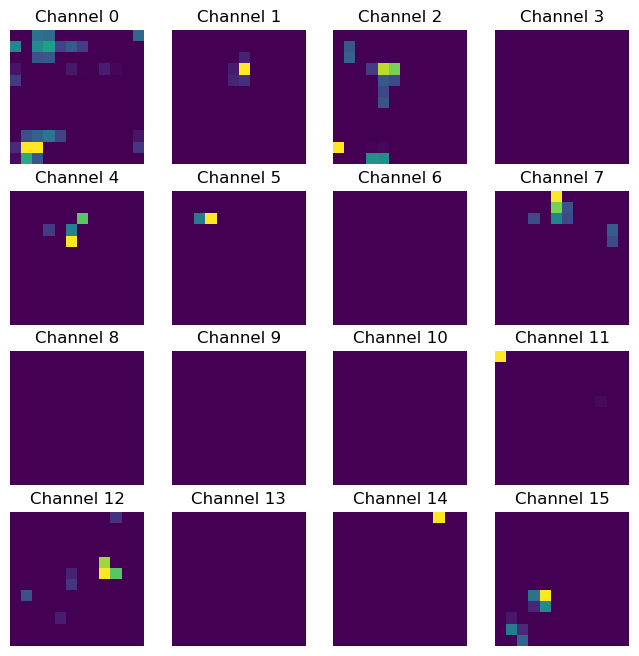

In [159]:
fig, axes = plt.subplots(4, 4, figsize=(8, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(spatial_map[:, :, i], cmap="viridis")
    ax.set_title(f"Channel {i}")
    ax.axis("off")

# Loss functions

In [151]:
def content_loss(base, combination):
    return tf.reduce_sum(tf.square(combination - base))

In [160]:
def gram_matrix(x):
    # Expects x with shape: (height, width, channels)
    features = tf.transpose(x, perm=(2, 0, 1))  # (C, H, W)
    features = tf.reshape(features, [tf.shape(features)[0], -1])  # (C, H*W)
    return tf.matmul(features, features, transpose_b=True)  # (C, C)

In [161]:
def style_loss(style, combination):
    S = gram_matrix(style)
    C = gram_matrix(combination)
    channels = 3
    size = img_height * img_width
    return tf.reduce_sum(tf.square(S - C)) / (4. * (channels ** 2) * (size ** 2))

In [169]:
def total_variation_loss(x):
    a = tf.square(
        x[:, :img_height - 1, :img_width - 1, :] -
        x[:, 1:, :img_width - 1, :])
    b = tf.square(
        x[:, :img_height - 1, :img_width - 1, :] -
        x[:, :img_height - 1, 1:, :])
    return tf.reduce_sum(tf.pow(a + b, 1.25))

In [184]:
outputs_dict = {layer.name: layer.output for layer in vgg.layers}
outputs_dict

{'input_layer_6': <KerasTensor shape=(None, None, None, 3), dtype=float32, sparse=False, name=keras_tensor_115>,
 'block1_conv1': <KerasTensor shape=(None, None, None, 64), dtype=float32, sparse=False, name=keras_tensor_116>,
 'block1_conv2': <KerasTensor shape=(None, None, None, 64), dtype=float32, sparse=False, name=keras_tensor_117>,
 'block1_pool': <KerasTensor shape=(None, None, None, 64), dtype=float32, sparse=False, name=keras_tensor_118>,
 'block2_conv1': <KerasTensor shape=(None, None, None, 128), dtype=float32, sparse=False, name=keras_tensor_119>,
 'block2_conv2': <KerasTensor shape=(None, None, None, 128), dtype=float32, sparse=False, name=keras_tensor_120>,
 'block2_pool': <KerasTensor shape=(None, None, None, 128), dtype=float32, sparse=False, name=keras_tensor_121>,
 'block3_conv1': <KerasTensor shape=(None, None, None, 256), dtype=float32, sparse=False, name=keras_tensor_122>,
 'block3_conv2': <KerasTensor shape=(None, None, None, 256), dtype=float32, sparse=False, name

In [185]:
feature_extractor = tf.keras.Model(
    inputs=vgg.input,
    outputs=outputs_dict,
)

In [186]:
all_features = feature_extractor(input_tensor, training=False)

In [199]:
content_layer = 'block5_conv2'
style_layers = ['block1_conv1', 'block2_conv1', 'block3_conv1', 'block4_conv1', 'block5_conv1']

In [175]:
total_variation_weight = 1e-4
style_weight = 1.
content_weight = 0.025

In [180]:
loss = tf.constant(0.0, dtype=tf.float32)
loss

<tf.Tensor: shape=(), dtype=float32, numpy=0.0>

In [202]:
layer_features = all_features[content_layer]
target_image_features = layer_features[0, :, :, :]
combination_features = layer_features[2, :, :, :]

In [205]:
target_image_features.shape

TensorShape([25, 25, 512])

In [ ]:
def compute_loss(loss):
    loss += content_weight * content_loss(target_image_features, combination_features)


In [208]:
loss += content_weight * content_loss(target_image_features, combination_features)
loss

<tf.Tensor: shape=(), dtype=float32, numpy=42448604.0>

In [210]:
for layer_name in style_layers:
    layer_features = all_features[layer_name]
    style_reference_features = layer_features[1, :, :, :]
    combination_features = layer_features[2, :, :, :]
    sl = style_loss(style_reference_features, combination_features)
    loss += (style_weight / len(style_layers)) * sl
loss += total_variation_weight * total_variation_loss(combination_image)  #

# Gradient Descent

In [212]:
import numpy as np
import tensorflow as tf


def get_loss_and_grads(x):
    # SciPy gives x as a flat NumPy array
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    x = tf.reshape(x, (1, img_height, img_width, 3))

    # Put the current SciPy image into the TensorFlow variable
    combination_image.assign(x)

    with tf.GradientTape() as tape:
        # This function must build the loss using combination_image
        loss_value = compute_loss()

    grad_values = tape.gradient(loss_value, combination_image)

    return loss_value, grad_values


class Evaluator:
    def __init__(self):
        self.loss_value = None
        self.grad_values = None

    def loss(self, x):
        assert self.loss_value is None

        loss_value, grad_values = get_loss_and_grads(x)

        self.loss_value = loss_value.numpy()
        self.grad_values = grad_values.numpy().flatten().astype("float64")

        return self.loss_value

    def grads(self, x):
        assert self.loss_value is not None

        grad_values = np.copy(self.grad_values)

        self.loss_value = None
        self.grad_values = None

        return grad_values


evaluator = Evaluator()